# 09. mAP@0.5:0.95 COCO 스타일 확장 실습

## 학습 목표
1. `mAP@0.5`와 `mAP@0.5:0.95` 차이를 이해한다.
2. IoU threshold 스윕 기반 AP 계산을 구현한다.
3. 클래스별/threshold별 성능 저하 패턴을 해석한다.

---

이 노트북은 08번 실습의 확장판으로,
IoU threshold를 `0.50, 0.55, ..., 0.95`로 바꿔가며 AP를 계산하고 평균냅니다.

In [1]:
from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

PROJECT_ROOT = Path("..").resolve()
DATA_ROOT = PROJECT_ROOT / "data" / "pcb-defect-dataset" / "pcb-defect-dataset"
OUT_DIR = PROJECT_ROOT / "outputs" / "detection_eval_coco"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = {
    0: "mouse_bite",
    1: "spur",
    2: "missing_hole",
    3: "short",
    4: "open_circuit",
    5: "spurious_copper",
}

IOU_THRESHOLDS = np.round(np.arange(0.50, 0.96, 0.05), 2)
print("IoU thresholds:", IOU_THRESHOLDS)

IoU thresholds: [0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95]


## 1) GT/Prediction 준비

08번과 동일한 방식으로 GT를 로드하고, 예측 결과를 생성(또는 로드)합니다.
실제 모델 추론 결과가 있다면 `preds`만 교체하면 됩니다.

In [2]:
def yolo_to_xyxy(cx, cy, w, h):
    return (cx - w/2, cy - h/2, cx + w/2, cy + h/2)


def load_gt(split="test", max_images=250):
    gt = defaultdict(list)
    img_dir = DATA_ROOT / split / "images"
    lbl_dir = DATA_ROOT / split / "labels"

    for img_path in sorted(img_dir.glob("*.jpg"))[:max_images]:
        lbl = lbl_dir / f"{img_path.stem}.txt"
        if not lbl.exists():
            continue

        text = lbl.read_text(encoding="utf-8").strip()
        if not text:
            continue

        for line in text.splitlines():
            p = line.split()
            if len(p) != 5:
                continue
            cls, cx, cy, w, h = map(float, p)
            cls = int(cls)
            if cls not in CLASS_NAMES:
                continue
            gt[img_path.stem].append({
                "class_id": cls,
                "bbox": yolo_to_xyxy(cx, cy, w, h),
            })
    return gt


def iou_xyxy(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)

    iw, ih = max(0.0, ix2-ix1), max(0.0, iy2-iy1)
    inter = iw * ih
    area_a = max(0.0, ax2-ax1) * max(0.0, ay2-ay1)
    area_b = max(0.0, bx2-bx1) * max(0.0, by2-by1)
    return inter / (area_a + area_b - inter + 1e-12)


rng = np.random.default_rng(123)

def clamp01(x):
    return max(0.0, min(1.0, x))


def jitter_box(box, s=0.03):
    x1, y1, x2, y2 = box
    dx = rng.normal(0, s, 4)
    nx1, ny1 = clamp01(x1+dx[0]), clamp01(y1+dx[1])
    nx2, ny2 = clamp01(x2+dx[2]), clamp01(y2+dx[3])
    if nx2 <= nx1: nx2 = clamp01(nx1 + 0.01)
    if ny2 <= ny1: ny2 = clamp01(ny1 + 0.01)
    return (nx1, ny1, nx2, ny2)


def random_box():
    x1, y1 = rng.uniform(0, 0.8, 2)
    w, h = rng.uniform(0.04, 0.25, 2)
    return (x1, y1, clamp01(x1+w), clamp01(y1+h))


def simulate_predictions(gt):
    preds = []
    for image_id, objs in gt.items():
        for o in objs:
            if rng.random() < 0.88:
                preds.append({
                    "image_id": image_id,
                    "class_id": o["class_id"],
                    "conf": float(rng.uniform(0.55, 0.99)),
                    "bbox": jitter_box(o["bbox"], s=0.02),
                })
        for _ in range(rng.integers(0, 3)):
            preds.append({
                "image_id": image_id,
                "class_id": int(rng.integers(0, 6)),
                "conf": float(rng.uniform(0.2, 0.85)),
                "bbox": random_box(),
            })
    return preds


gt = load_gt(split="test", max_images=250)
preds = simulate_predictions(gt)

print("GT images:", len(gt))
print("GT boxes:", sum(len(v) for v in gt.values()))
print("Pred boxes:", len(preds))

GT images: 250
GT boxes: 506
Pred boxes: 694


## 2) IoU threshold별 AP 계산 함수

핵심 포인트:
- class별 confidence 정렬
- greedy matching (각 GT는 1회만 매칭)
- PR 적분으로 AP 계산

In [3]:
def prepare_gt_by_class(gt):
    out = defaultdict(lambda: defaultdict(list))
    for image_id, objs in gt.items():
        for o in objs:
            out[o["class_id"]][image_id].append({"bbox": o["bbox"], "used": False})
    return out


def ap_for_class_iou(preds, gt, class_id, iou_thr=0.5):
    gt_cls = prepare_gt_by_class(gt)[class_id]
    n_gt = sum(len(v) for v in gt_cls.values())

    pred_cls = [p for p in preds if p["class_id"] == class_id]
    pred_cls = sorted(pred_cls, key=lambda x: x["conf"], reverse=True)

    if n_gt == 0:
        return np.nan, np.array([]), np.array([])

    tp = np.zeros(len(pred_cls), dtype=np.float32)
    fp = np.zeros(len(pred_cls), dtype=np.float32)

    for i, p in enumerate(pred_cls):
        image_id = p["image_id"]
        gts = gt_cls.get(image_id, [])

        best_iou, best_j = 0.0, -1
        for j, g in enumerate(gts):
            iou = iou_xyxy(p["bbox"], g["bbox"])
            if iou > best_iou:
                best_iou, best_j = iou, j

        if best_iou >= iou_thr and best_j >= 0 and not gts[best_j]["used"]:
            tp[i] = 1.0
            gts[best_j]["used"] = True
        else:
            fp[i] = 1.0

    ctp = np.cumsum(tp)
    cfp = np.cumsum(fp)

    rec = ctp / (n_gt + 1e-12)
    prec = ctp / (ctp + cfp + 1e-12)

    # precision envelope + 적분
    mrec = np.concatenate(([0.0], rec, [1.0]))
    mpre = np.concatenate(([0.0], prec, [0.0]))
    for k in range(len(mpre)-1, 0, -1):
        mpre[k-1] = max(mpre[k-1], mpre[k])
    idx = np.where(mrec[1:] != mrec[:-1])[0]
    ap = np.sum((mrec[idx+1] - mrec[idx]) * mpre[idx+1])

    return float(ap), rec, prec


def evaluate_map_range(preds, gt, class_names, iou_thresholds):
    records = []
    pr_cache = {}  # (class_id, iou_thr) -> (rec, prec)

    for t in iou_thresholds:
        for cid in sorted(class_names):
            ap, rec, prec = ap_for_class_iou(preds, gt, cid, iou_thr=float(t))
            records.append({
                "iou_thr": float(t),
                "class_id": cid,
                "class_name": class_names[cid],
                "AP": ap,
            })
            pr_cache[(cid, float(t))] = (rec, prec)

    ap_df = pd.DataFrame(records)
    map_per_thr = ap_df.groupby("iou_thr")["AP"].mean().rename("mAP").reset_index()
    map_50 = map_per_thr.loc[np.isclose(map_per_thr["iou_thr"], 0.50), "mAP"].values[0]
    map_5095 = map_per_thr["mAP"].mean()

    return ap_df, map_per_thr, float(map_50), float(map_5095), pr_cache

In [4]:
ap_df, map_per_thr, map50, map5095, pr_cache = evaluate_map_range(
    preds=preds,
    gt=gt,
    class_names=CLASS_NAMES,
    iou_thresholds=IOU_THRESHOLDS,
)

print(f"mAP@0.50       = {map50:.4f}")
print(f"mAP@0.50:0.95  = {map5095:.4f}")

display(map_per_thr)
display(ap_df.head(12))

mAP@0.50       = 0.0461
mAP@0.50:0.95  = 0.0087


,iou_thr,mAP
0,0.50,0.046134
1,0.55,0.023600
2,0.60,0.011672
3,0.65,0.003902
4,0.70,0.001992
5,0.75,0.000099
6,0.80,0.000019
7,0.85,0.000000
8,0.90,0.000000
9,0.95,0.000000


,iou_thr,class_id,class_name,AP
0,0.50,0,mouse_bite,0.006096
1,0.50,1,spur,0.150961
2,0.50,2,missing_hole,0.022469
3,0.50,3,short,0.056965
4,0.50,4,open_circuit,0.032172
5,0.50,5,spurious_copper,0.008140
6,0.55,0,mouse_bite,0.004938
7,0.55,1,spur,0.069100
8,0.55,2,missing_hole,0.018380
9,0.55,3,short,0.025606


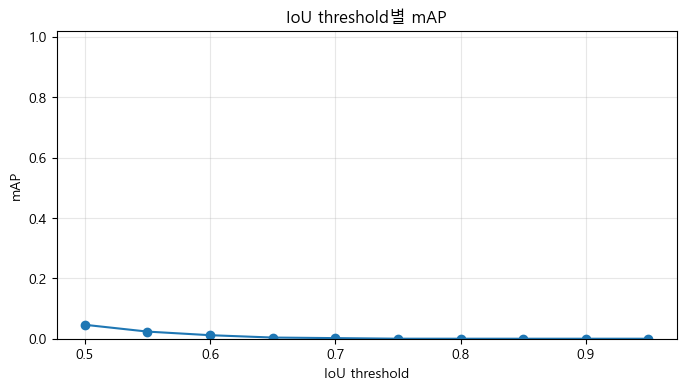

In [5]:
# IoU threshold가 커질수록 mAP가 어떻게 변하는지
plt.figure(figsize=(8, 4))
plt.plot(map_per_thr["iou_thr"], map_per_thr["mAP"], marker="o")
plt.title("IoU threshold별 mAP")
plt.xlabel("IoU threshold")
plt.ylabel("mAP")
plt.ylim(0, 1.02)
plt.grid(alpha=0.3)
plt.show()

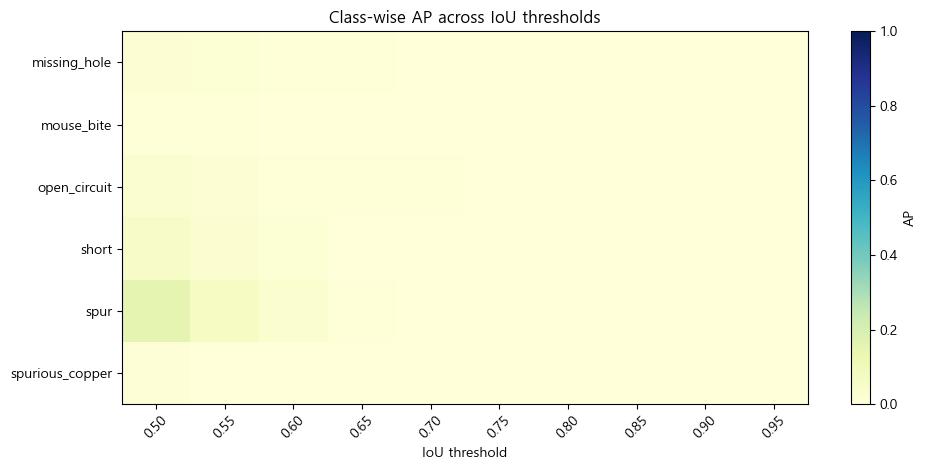

iou_thr,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90,0.95
class_name,,,,,,,,,,
missing_hole,0.022469,0.018380,0.007724,0.005785,0.000567,0.000142,0.000000,0.0,0.0,0.0
mouse_bite,0.006096,0.004938,0.003472,0.001929,0.000000,0.000000,0.000000,0.0,0.0,0.0
open_circuit,0.032172,0.020454,0.007780,0.006506,0.006506,0.000000,0.000000,0.0,0.0,0.0
short,0.056965,0.025606,0.016388,0.001821,0.001821,0.000455,0.000114,0.0,0.0,0.0
spur,0.150961,0.069100,0.032233,0.007226,0.003061,0.000000,0.000000,0.0,0.0,0.0
spurious_copper,0.008140,0.003121,0.002437,0.000146,0.000000,0.000000,0.000000,0.0,0.0,0.0


In [6]:
# 클래스별 AP heatmap (class x iou_thr)
pivot = ap_df.pivot(index="class_name", columns="iou_thr", values="AP")

plt.figure(figsize=(10, 4.8))
im = plt.imshow(pivot.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=1)
plt.colorbar(im, label="AP")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(len(pivot.columns)), [f"{x:.2f}" for x in pivot.columns], rotation=45)
plt.title("Class-wise AP across IoU thresholds")
plt.xlabel("IoU threshold")
plt.tight_layout()
plt.show()

display(pivot)

## 3) PR 곡선 비교 (IoU 0.50 vs 0.75)

같은 클래스라도 IoU 기준이 엄격해지면 PR 곡선이 보통 아래로 내려갑니다.

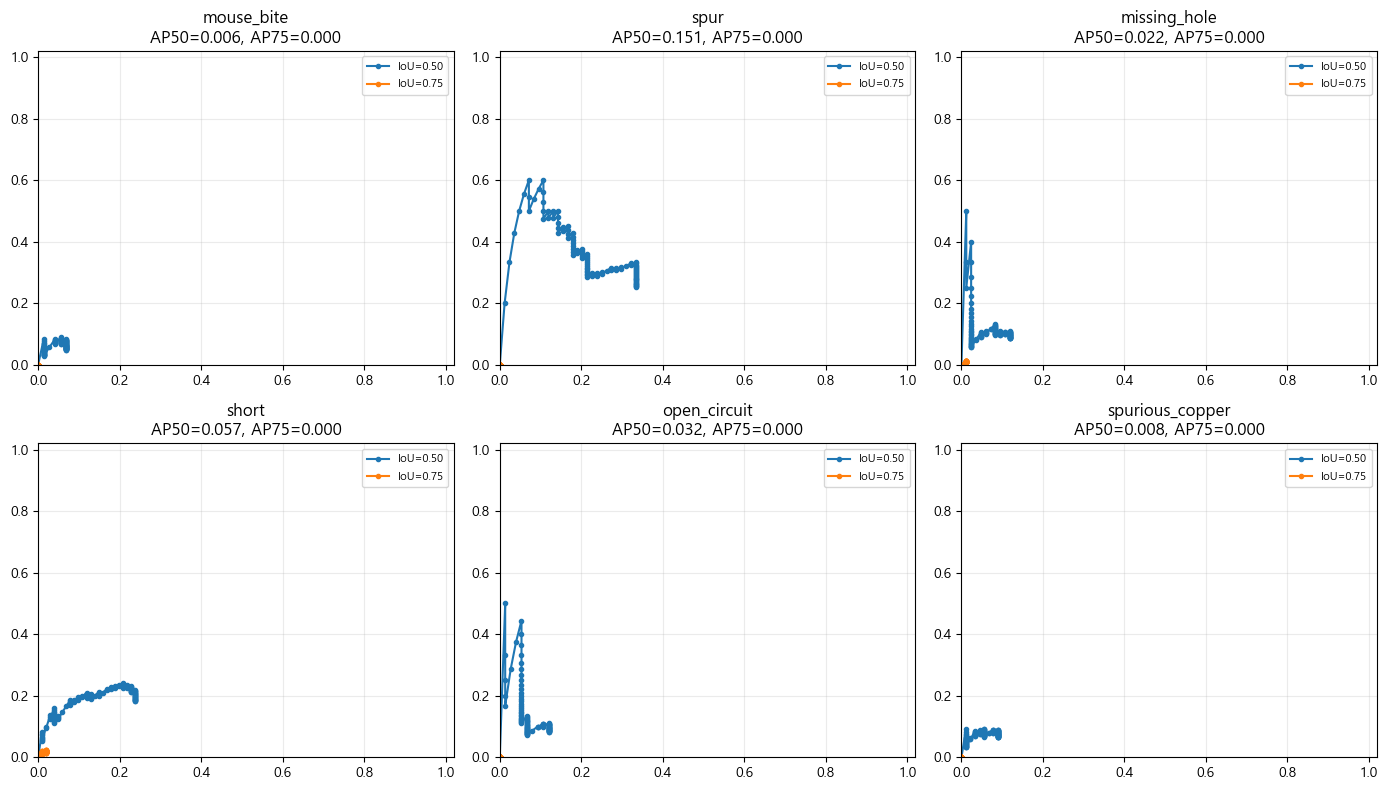

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, cid in enumerate(sorted(CLASS_NAMES)):
    ax = axes[i]

    rec50, prec50 = pr_cache[(cid, 0.5)]
    rec75, prec75 = pr_cache[(cid, 0.75)]

    if len(rec50):
        ax.plot(rec50, prec50, marker=".", label="IoU=0.50")
    if len(rec75):
        ax.plot(rec75, prec75, marker=".", label="IoU=0.75")

    ap50 = ap_df[(ap_df.class_id == cid) & (np.isclose(ap_df.iou_thr, 0.5))]["AP"].iloc[0]
    ap75 = ap_df[(ap_df.class_id == cid) & (np.isclose(ap_df.iou_thr, 0.75))]["AP"].iloc[0]

    ax.set_title(f"{CLASS_NAMES[cid]}\nAP50={ap50:.3f}, AP75={ap75:.3f}")
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
# 결과 저장
ap_df.to_csv(OUT_DIR / "ap_by_class_iou.csv", index=False, encoding="utf-8-sig")
map_per_thr.to_csv(OUT_DIR / "map_by_iou_threshold.csv", index=False, encoding="utf-8-sig")

summary = pd.DataFrame([
    {"metric": "mAP@0.50", "value": map50},
    {"metric": "mAP@0.50:0.95", "value": map5095},
])
summary.to_csv(OUT_DIR / "summary_map50_95.csv", index=False, encoding="utf-8-sig")

display(summary)
print("저장 완료:")
print("-", OUT_DIR / "ap_by_class_iou.csv")
print("-", OUT_DIR / "map_by_iou_threshold.csv")
print("-", OUT_DIR / "summary_map50_95.csv")

,metric,value
0,mAP@0.50,0.046134
1,mAP@0.50:0.95,0.008742


저장 완료:
- C:\MyCursorLab\10_프로젝트\outputs\detection_eval_coco\ap_by_class_iou.csv
- C:\MyCursorLab\10_프로젝트\outputs\detection_eval_coco\map_by_iou_threshold.csv
- C:\MyCursorLab\10_프로젝트\outputs\detection_eval_coco\summary_map50_95.csv


## 실습 과제

1. IoU threshold 구간을 0.30~0.95로 넓혀 민감도 변화를 관찰하세요.
2. confidence calibration(예: temperature scaling)을 적용했다고 가정하고 PR 변화를 비교하세요.
3. 클래스별 bbox 크기(작은 결함 vs 큰 결함)에 따라 AP 저하 패턴을 분석하세요.
4. 실제 모델 추론 결과를 `preds`에 넣어 리얼 성능 평가 리포트를 만들어 보세요.

---

### 한 줄 정리
`mAP@0.50`은 관대한 성능, `mAP@0.50:0.95`는 위치 정밀도까지 반영한 더 엄격한 성능 지표입니다.